Importing necessary libraries

In [29]:
import numpy as np
from random import random
import matplotlib.pyplot as plt

## **Question 1:**

In [ ]:
n1 = int(input("Enter number 1: "))
n2 = int(input("Enter number 2: "))

r = round(n1 + random()*(n2-n1))
print(f"Random number: {r}")

Random number: 26


## **Question 2:**

In [ ]:
# Number of trials
N = int(1e5)
count = 0

# Function to check if both have met or not
def hasmet():
    tA, tB = 30*random(), 30*random()

    if tB>tA and tB-tA < 5:
        return True
    elif tA>tB and tA-tB < 10:
        return True
    else:
        return False

# Running trials
for i in range(N):
    if hasmet():
        count += 1

# Calculating probability
prob = count/N
print(f"Probability of meeting: {prob}")

Probability of meeting: 0.43082


## **Question 3:**

Random variables:

$x$ = distance of center of needle from the closest line \
$\theta$ = angle with line

*Case 1: $l \leq d$*
$$P = \frac{2l}{\pi d}$$

*Case 2: $l \gt d$*
$$P = \frac{2}{\pi} \left[\frac{l}{d} - \sqrt{\left(\frac{l}{d} \right)^2 - 1} + \cos^{-1}\left(\frac{d}{l} \right) \right]$$

Defining functions

In [76]:
# Function for running simulation N times and calculating probability
def buffon_needle(N, l, d):
    count = 0

    # Calculating probability of crossing
    for _ in range(N):
        theta = np.pi*random()  # Random angle
        x = (d/2)*random()      # Random center of needle

        # Crossing condition
        if (l/2)*np.sin(theta) >= x:    
            count += 1
        
    return count/N

# Theoretical probability
def prob_theory(l, d):
    if l <= d:
        return 2*l/(np.pi*d)
    else:
        return (2/np.pi)*((l/d)-np.sqrt((l/d)**2 - 1) + np.arccos(d/l))
    

Calculating probability

In [79]:
# Parameters
N = int(1e4)
l = 2
d = 1

p_expt = buffon_needle(N, l, d)
p_theo = prob_theory(l, d)

print(f"Experimental Probability: {p_expt}")
print(f"Theoretical Probability: {p_theo}")

Experimental Probability: 0.8433
Theoretical Probability: 0.8372484205582454


## **Question 4:**

Defining functions for random walk

In [ ]:
# Taking a single step
def step():
    s = random()

    if s > 0.5:
        return 1
    else:
        return -1

# Single random walker with fixed steps  
def random_walk(steps):
    pos = 0
    for i in range(steps):
        pos += step()
    
    return pos

# Theoretical probability function for reaching position n after N steps
def prob(n, num_steps):
    return 2/np.sqrt(2*np.pi*num_steps)*np.exp(-n**2/(2*num_steps))


Implementing the random walk

In [ ]:
# Parameters
N = int(1e5)
num_steps = 50
final_pos = np.zeros(num_steps+1)

# Random walk of all walkers
for i in range(N):
    pos = random_walk(num_steps)
    index = int((pos+num_steps)/2)
    final_pos[index] += 1

# Calculating probability
final_pos = final_pos/N

# Possible final positions
positions = np.linspace(-num_steps, num_steps, num_steps+1)
pos_th = prob(positions, num_steps)

Plotting

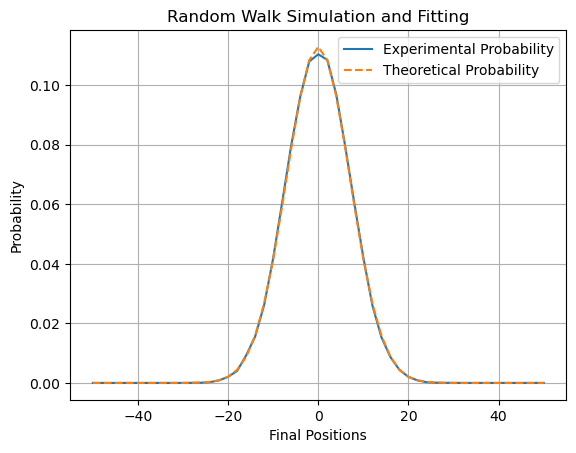

In [84]:
plt.plot(positions, final_pos, label = "Experimental Probability")
plt.plot(positions, pos_th, '--', label = "Theoretical Probability")
plt.xlabel("Final Positions")
plt.ylabel("Probability")
plt.title("Random Walk Simulation and Fitting")

plt.legend()
plt.grid()
plt.show()

The average final position of several random walkers walking for the same number of steps forms a Gaussian curve. The mean is at 0, which means that majority of the random walkers end up at the origin itself (from where they started). As we go towards positions away from the origin, their probability decreases.

The experimental data matches with the theoretical probability function. The convergence gets better as we increase N, i.e., the number of walkers.

## **Question 5:**

Implementing random walk and calculating $\langle x^2 \rangle$

In [72]:
# Parameters
N = int(1e5)
num_steps = 50
pos_walker = np.zeros(N)    # Stores updated position of random walkers after every step
x2_avg = np.zeros(num_steps)    # Stores x^2/N for all x in pos_walker after every step

# Taking each step
for s in range(num_steps):
    # Averaging positions for all random walkers
    x2_avg[s] = np.sum(pos_walker**2)/N

    # Updating positions of random walkers
    for walker in range(N):
        pos_walker[walker] += step()

# x-axis
steps = np.linspace(0, num_steps-1, num_steps)

Plotting

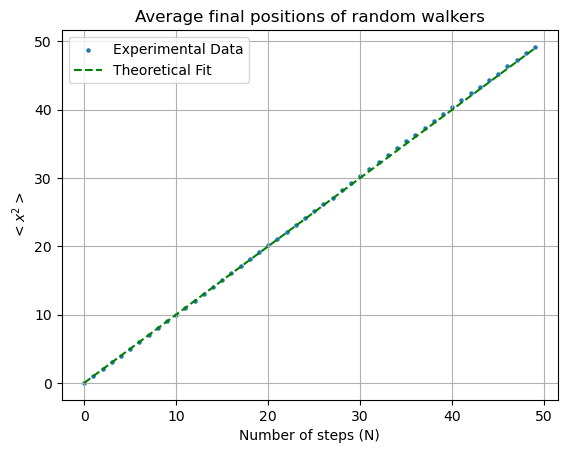

In [83]:
plt.scatter(steps, x2_avg, s=5, label="Experimental Data")
plt.plot(steps, steps, 'g--', label="Theoretical Fit")
plt.xlabel("Number of steps (N)")
plt.ylabel("$<x^2>$")
plt.title("Average final positions of random walkers")

plt.legend()
plt.grid()
plt.show()